# Homework assignment



> Oskar Krawczyk, AIML22 Group 3





---

As part of this homework assignment, we will go through topics covered in week 2 of Lady Margaret Hall Summer Programme, specifically computer vision for object classification using pretrained transformers: ViT-B/16 (Vision Transformer Base with 16x16 patch size) and Swin-T (Shifted Window Transformer) from the Tiny Family (which refers to its number of parameters). To do so, we will create a custom dataset based on the [Cell types dataset](https://www.kaggle.com/competitions/cell-type-prediction/data). Then, we will consider a model based on the combination of ViT and Swin Transformers, train it on the custom dataset and eventually evaluate its results using various image classification metrics - in particular accuracy.

In the following notebook, I split my solution into six separate sections - Part 1, 2, 3, 4, 5, 6 - which follow the convention used in the initial [ViT_Swin_Assignment.ipynb](https://www.dropbox.com/scl/fi/v1fxjy1dktpf7990u2gy6/ViT_Swin_SlidingWindow_Cells_Classification_Homework_Assignment.ipynb?rlkey=4al6imarpkykxs671bm3fl8g3&st=vxjmvkkj&e=1&dl=0) notebook. Each section includes the code as part of my solution as well as a brief explanation of certain concepts not mentioned during lectures/seminars. At the end of this notebook, I also denote resources used to complete and/or improve the final results and additional steps I have taken (beyond the required ones) to complete the notebook.

---



## Part 1

In this section we first import all necessary libraries into a single cell. The reason is that in the future if someone tries to access the very same code, it is preferable to keep it in the single cell instead of having imports scattered across the entire notebook. Then, we set up the notebook by specifying settings for plotting (matplotlib/seaborn), device and verify versions of libraries imported. Finally, we download the dataset, process it and, at the end, we explore its structure further (number of classes, samples, etc.).

The following cell is optional, nonetheless it is highly recommended since, depending on the environment and settings, some packages might not be included in the standard setup. While debugging, removing -qq might be beneficial since this flag displays critical erros only.

In [91]:
!pip install -qq kagglehub numpy pandas matplotlib seaborn torch torchvision tqdm pillow scikit-learn

#### Library Imports

In [125]:
import os
import kagglehub
import random
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

from matplotlib import rcParams

#### Notebook setup

Here, we configure the default settings for the notebook. First, we set the random seed to ensure the reproducibility of the results. Then, based on my preferences, we configure the default settings for matplotlib and seaborn packages to ensure consistent plotting. Finally, we display information regarding the imported libraries - if any methods change in the future versions of these packages, this is a reference point.

In [93]:
random.seed(2026)
np.random.seed(2026)
torch.manual_seed(2026)
torch.cuda.manual_seed(2026)
torch.cuda.manual_seed_all(2026)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

sns.set_theme(style = "darkgrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Notebook setup info ---")
print(f"Device:        {device}")
print(f"PyTorch:       {torch.__version__}")
print(f"Numpy:         {np.__version__}")

--- Notebook setup info ---
Device:        cuda
PyTorch:       2.11.0+cu128
Numpy:         2.0.2


#### Download the data

There are two options for obtaining the cell types dataset so that we can use it in this notebook and our choice is determined by what we want to achieve. If we do care about independence from the environment used - whether we are running the code on Google Colab, local Jupyter via Anaconda or remote servers - the best option is to manually download the entire dataset. This way, regardless of where we are, we can store it locally and work on it directly. The second method is using cached datasets provided by Google Colab or downloading the dataset via kagglehub we imported above.

Nevertheless, we need to keep in mind that on Google Colab, we will not be downloading the dataset directly into our project, but instead we will use a cache which in turn can speed up data loading, whereas running the code locally will simply download the dataset, making this method almost equally universal to the first one.

Considering both options, we shall use the second method by default, yet we leave the first one commented out so that you can use it if you want to.

**Note**: Using either of them should not cause any errors or problems with notebook's execution.

##### Downloading directly

In [94]:
# !kaggle datasets download -d mohammad2012191/cells-types --force --unzip -p ./cells_dataset # Run if you want to download the data regardless of the environment.

In [95]:
# dataset_path = "./cells_dataset/data.csv"
# images_dir = "./cells_dataset/images"

##### Downloading using kagglehub

In [96]:
raw_path = kagglehub.dataset_download("mohammad2012191/cells-types", force_download = True)

dataset_path = glob.glob(os.path.join(raw_path, "*.csv"))[0]
images_dir = os.path.join(raw_path, "images")

Using Colab cache for faster access to the 'cells-types' dataset.


#### Process & Explore the data

Here we first read the CSV file and extract the data we will be working on. Then, we optimise memory usage by casting the labels to a categorical type - we might as well do it using strings, but it is a better practice to use "category" instead of "string" type. Net, we extract unique cell types, sort them alphabetically to ensure consistent behaviour across different runs and map them to numerical indices (label encoding since it is a requirement for PyTorch pretrained models we will utilise). Finally, we perform a stratified split to divide the data into training, validation and test sets.

In [97]:
data = pd.read_csv(dataset_path)

In [98]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2578 entries, 0 to 2577
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         2578 non-null   int64 
 1   cell_type  2578 non-null   object
dtypes: int64(1), object(1)
memory usage: 40.4+ KB
None


As we can see, the dataset itself is already free of null values. What can be noticed, however, is that the cell_type is not a string, but an object. To change it we will use pandas "category" type which behaves like a string, but internally is implemented in a different way. This in turn allows the data to be stored in a custom order and to more efficiently store the data. [Source](https://pbpython.com/pandas_dtypes_cat.html#:~:text=The%20category%20data%20type%20in,more%20efficiently%20store%20the%20data.)

In [99]:
data["cell_type"] = data["cell_type"].astype("category")

print(data.dtypes)

id              int64
cell_type    category
dtype: object


Having said that, we can now collect all available classes and create a 1:1 mapping between these cell types/labels and their corresponding indices, therefore performing label encoding.

In [100]:
classes = list(sorted(data["cell_type"].unique()))
label2idx = {label: idx for idx, label in enumerate(classes)}

print("Mapping cell types to indices\n")
for item in label2idx:
    value = label2idx[item]
    print(f"{value} -> {item}")

Mapping cell types to indices

0 -> astro
1 -> cort
2 -> shsy5y


In [101]:
data["label"] = data["cell_type"].map(label2idx)

Having the data prepared, we can now perform stratified train/test/validation split with a ratio of 70%/15%/15% with labels criterion. We will see why it actually matters and whether it is indeed performed properly in the upcoming sections while exploring the dataset.

**Note**: Stratified split is a data sampling method that divided a dataset so that the proportion of each class or category remains the same in both the training and testing subsets. [Source](https://medium.com/@becaye-balde/why-you-should-use-stratified-split-bddb6dadd34e)

In [102]:
train_data, temp_data = train_test_split(data, train_size = .7, stratify = data["cell_type"], random_state = 2026)

valid_data, test_data = train_test_split(temp_data, test_size = .5, stratify = temp_data["cell_type"], random_state = 2026)

In [103]:
print("Dataset - Cell Types - has been configured successfully.\n")

print("--- Dataset information ---")
print(f"Dataset size:         {len(data)}")
print(f"Train set size:       {len(train_data)}")
print(f"Test  set size:       {len(test_data)}")
print(f"Validation set size:  {len(valid_data)}\n")

print("Classes in the dataset")
for item in label2idx:
    print(f"{label2idx[item]}:   {item}")

Dataset - Cell Types - has been configured successfully.

--- Dataset information ---
Dataset size:         2578
Train set size:       1804
Test  set size:       387
Validation set size:  387

Classes in the dataset
0:   astro
1:   cort
2:   shsy5y


Before we move to defining the dataset, we will perform a qucik sanity check (in case some indices of images are missing or some images have extensions of .jpg instead of .png). In such cases we will simply remove them from the dataset.

In [104]:
data["image_path"] = data["id"].astype(str).apply(lambda x: os.path.join(images_dir, x + ".png"))

missing_files = ~data["image_path"].apply(os.path.exists)
missing_png = ~data["image_path"].str.endswith(".png")

invalid_files = data[missing_files | missing_png]

if not invalid_files.empty:
    print("Invalid files found:")
    print(invalid_files)

    data = data.drop(invalid_files.index).reset_index(drop = True)
else:
    print("No invalid files found.")

No invalid files found.


As we can see now, there are no missing files and each image is of a valid type, that is .png.

## Part 2

In this section we will go deeper into the data we downloaded in the previous section. We start by initialising data transformations that will be applied to  train, test and validation datasets. Then, we create the CellDataset class which inherits from torch Dataset. Eventually, we transform our extracted data into the datasets and then explore its structure.

#### Explore transformations

We start by defining well-known Imagenet stats used to normalise images in the dataset in the form of $[\mu, \sigma]$ where $\mu$ - mean and $\sigma$ - standard deviation. Then, we initialise image transformations (imposed in the initial notebook) which we then apply to the datasets.

Beyond what has been said in the initial notebook, we add additional transformation - ToTensor - mainly because of the fact that since we are working with PyTorch models, it is better to convert everything into tensors. Furthermore, intuitively adding solely RandomHorizontalFlip should not impact the model's performance negatively, but considering that we are dealing with cell images which lack an orientation, we also introduce RandomVerticalFlip. I believe, this addition will enhance the data augmentation by providing the model with a greater number of cells' representations.

In [105]:
IMAGENET_STATS = [[0.485, 0.456, 0.406], [0.229, 0.224, 0.225]]

train_transforms = transforms.Compose([
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*IMAGENET_STATS)
])

test_transforms = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(*IMAGENET_STATS)
])

valid_transforms = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(*IMAGENET_STATS)
])

#### Define dataset

In [106]:
class CellDataset(Dataset):
    '''
    Custom dataset class for handling Cell Types data.
    '''

    def __init__(self, data, images_dir, label2idx, transform = None, split = "train"):
        '''
        Initialises a new instance of the CellDataset class.
        Args:
            data (pd.DataFrame): A pandas DataFrame containing the data.
            images_dir (str): The directory containing the images.
            label2idx (dict): A dictionary mapping labels to indices.
            transform (callable, optional): A function/transform that takes in an image and returns a transformed version.
            split (str, optional): The split of the dataset ("train" or "test" or "valid").

        '''

        super().__init__()
        self.data = data
        self.images_dir = images_dir
        self.label2idx = label2idx
        self.transform = transform

        self.num_classes = len(label2idx)
        self.split = split

        self.idx2label = {idx: label for label, idx in label2idx.items()}

    def __len__(self):
        '''
        Returns the number of samples in the dataset.
        '''

        return len(self.data)

    def __getitem__(self, idx):
        '''
        Returns a single sample from the dataset.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the image and its corresponding label.
        '''

        row = self.data.iloc[idx]

        image_name = str(row["id"]) + ".png"

        image_path = os.path.join(self.images_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

    def __str__(self):
        '''
        Returns a string representation of the dataset.
        '''

        dataset_name = self.__class__.__name__

        statistics = (
            "----------------------------------------------\n"
            "\n"
            f"Dataset: \033[1m{dataset_name} | {self.split}\033[0m\n"
            f"Number of classes: {self.num_classes}\n"
            f"Number of images: {len(self.data)}\n"
            f"Classes: {', '.join(self.label2idx.keys())}\n"
            "\n"
            "----------------------------------------------"
        )

        return statistics


    def visualise_sample(self, index: int, figsize: tuple = rcParams["figure.figsize"]):
        '''
        Visualises a single sample from the dataset.

        Args:
            index (int): Index of the sample to visualise.
            figsize (tuple): Size of the figure. (optional)
        '''

        image, label = self.__getitem__(index)

        image = image.permute(1, 2, 0).numpy()

        mean, std = np.array(IMAGENET_STATS[0]), np.array(IMAGENET_STATS[1])

        image = std * image + mean
        image = np.clip(image, 0, 1)

        label = self.data.iloc[index]["cell_type"]
        channel_img = image[:, :, 0]

        plt.figure(figsize = figsize)
        plt.imshow(channel_img, cmap = "RdPu")
        plt.title(f"Label: {label}")
        plt.axis(False)
        plt.show()

In [107]:
train_dataset = CellDataset(train_data, images_dir, label2idx, train_transforms)
test_dataset = CellDataset(test_data, images_dir, label2idx, test_transforms, split = "test")
valid_dataset = CellDataset(valid_data, images_dir, label2idx, valid_transforms, split = "valid")

In [108]:
print("Datasets descriptions\n")

print(train_dataset)
print(valid_dataset)
print(test_dataset)

Datasets descriptions

----------------------------------------------

Dataset: CellDataset | train
Number of classes: 3
Number of images: 1804
Classes: astro, cort, shsy5y

----------------------------------------------
----------------------------------------------

Dataset: CellDataset | valid
Number of classes: 3
Number of images: 387
Classes: astro, cort, shsy5y

----------------------------------------------
----------------------------------------------

Dataset: CellDataset | test
Number of classes: 3
Number of images: 387
Classes: astro, cort, shsy5y

----------------------------------------------


#### Explore the data

Given the datasets defined above, we can now explore the data and especially examine its structure which is a significant step towards understanding it properly to later properly prepare the training and evalutaion phases. To do so, we first analyse the classes distribution which has been imposed by the stratified split in the previous section. Finally, we visualise a few samples to better understand what we are dealing with.

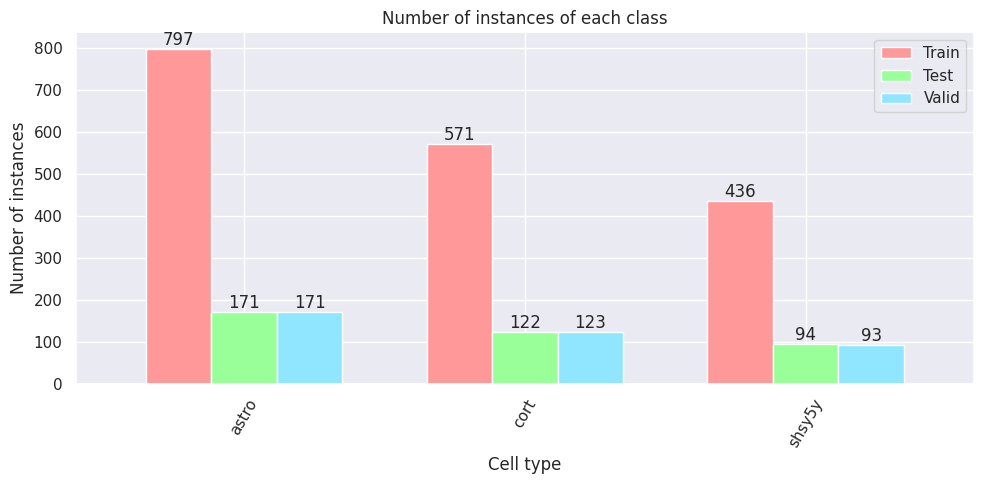

In [109]:
train_counter = train_data["cell_type"].value_counts()
test_counter = test_data["cell_type"].value_counts()
valid_counter = valid_data["cell_type"].value_counts()

distributions = pd.DataFrame({"Train": train_counter, "Test": test_counter, "Valid": valid_counter})

ax = distributions.plot(kind = "bar", figsize = (10, 5), width = .7, color = ["#FF9999", "#99FF99", "#91E6FF"])

for c in ax.containers:
    ax.bar_label(c)

plt.title("Number of instances of each class")
plt.xlabel("Cell type")
plt.ylabel("Number of instances")
plt.xticks(rotation = 60)
plt.tight_layout()
plt.show()

It is clear that the stratified split performed in section 1 properly distributed the data into three distinct categories depending on the stage in which they will be used. Furthermore, the visualisation reveals an inherent class imbalance within the dataset, with the **astro** cell type being the most prevalent and **shsy5y** the least. We will examine if that has an impact in our particular case, specifically in the last part during evaluation phase.

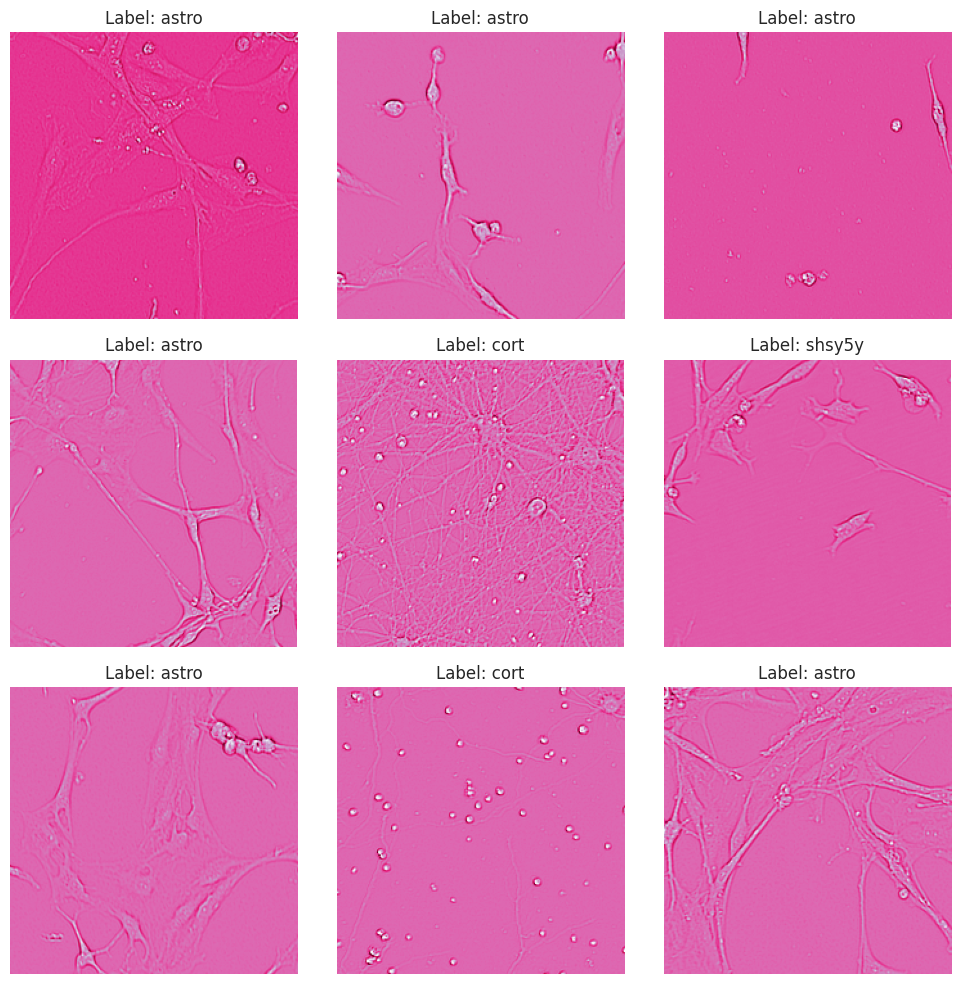

In [110]:
fig, ax = plt.subplots(3, 3, figsize = (10, 10))
ax = ax.flatten()

random_samples = random.sample(range(len(train_dataset)), 9)

mu, sigma = np.array(IMAGENET_STATS[0]), np.array(IMAGENET_STATS[1])

for i, idx in enumerate(random_samples):
    image, label = train_dataset[idx]

    image = image.permute(1, 2, 0).numpy()
    image = sigma * image + mu
    image = np.clip(image, 0, 1)

    ax[i].imshow(image)
    ax[i].set_title(f"Label: {train_dataset.idx2label[label]}")

    image_ch = image[:, :, 0]
    ax[i].imshow(image_ch, cmap = "PuRd")
    ax[i].axis(False)

plt.tight_layout()
plt.show()

WNIOSEK

## Part 3

In this section we define the batch size and wrap the datasets created in the previous section into dataloaders. What can be potentially interesting in this section is that we shuffle the training dataset, but leave the validation and test sets unshuffled.

**Note**: Shuffling the training data prevents the NN from memorising the sequence of samples, forcing it to generalise instead. Since the validation and test sets are used purely in the latter stage of evaluation and no weght updates occur during these stages, shuffling them has no benefit and enables code's reproducibility.

In [112]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 2)
valid_loader = DataLoader(valid_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 2)

## Part 4

In this section we define a model by combining two state-of-the-art Vision Transformer architectures, that is ViT-B/16 and Swin-T. While ViT is good at capturing global context across the image, Swin Transformer introduced hierarchical, localised attention. From extracting features from both pretrained backbones and concatenatim them, the model can cummulate global as well as local structures. To prevent overfitting and avoid potential gradient vanishing of pretrained weights from ImageNet dataset, we replace the classification heads with an identity mapping, apply dropout and properly tune hyperparameters, specifically reasonably low batch size and learning rate.

In [113]:
class ViTSwinConcat(nn.Module):
    '''
    Custom model class for combining ViT-B/16 and Swin-T Vision Transformers.
    '''

    def __init__(self):
        '''
        Initialises a new instance of the ViTSwinConcat class.
        '''

        super().__init__()

        self.vit = torchvision.models.vit_b_16(pretrained = True)
        self.swin = torchvision.models.swin_t(pretrained = True)

        self.vit.heads = nn.Identity()
        self.swin.head = nn.Identity()

        self.dropout = nn.Dropout(p = 0.1)

        self.classifier = nn.Linear(in_features = 768 + 768, out_features = 3)

    def forward(self, x):
        '''
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.
        '''

        vit_output = self.vit(x)
        swin_output = self.swin(x)

        concat = torch.cat((vit_output, swin_output), dim = 1)
        concat = self.dropout(concat)
        output = self.classifier(concat)

        return output

After experimentation with various values of learning rate hyperparameter, it turned out that the best value is 0.0001.

In [114]:
LR = 0.0001

model = ViTSwinConcat().to(device)
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(params = model.parameters(), lr = LR)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_T_Weights.DEFAULT` to get the most up-to-date weights.

ViTSwinConcat(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): Lay

## Part 5

#### Define train and validation epochs

In [115]:
def train_epoch(model, dataloader, loss_fn, optimiser, device):
    '''
    Trains the model for one epoch.

    Args:
        model (torch.nn.Module): The model to train.
        dataloader (torch.utils.data.DataLoader): The dataloader for the training data.
        loss_fn (torch.nn.Module): The loss function to use.
        optimiser (torch.optim.Optimizer): The optimiser to use.
        device (torch.device): The device to use for training.

    Returns:
        tuple: A tuple containing the training loss and accuracy.
    '''

    model.train()
    train_loss = 0.0
    correct = 0

    for images, labels in tqdm(dataloader, desc = "Training loop"):
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimiser.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

    train_loss /= len(dataloader)
    accuracy = correct / len(dataloader.dataset)

    return train_loss, accuracy

In [116]:
def test_epoch(model, dataloader, loss_fn, device):
    '''
    Tests the model for one epoch.

    Args:
        model (torch.nn.Module): The model to test.
        dataloader (torch.utils.data.DataLoader): The dataloader for the validation data.
        loss_fn (torch.nn.Module): The loss function to use.
        device (torch.device): The device to use for testing.

    Returns:
        tuple: A tuple containing the validation loss and accuracy.
    '''

    model.eval()
    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc = "Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

        test_loss /= len(dataloader)
        accuracy = correct / len(dataloader.dataset)

    return test_loss, accuracy

#### Perform training

I have performed multiple various training phases with various parameters, especially the number of epochs and optimisers. What has been consistent throughout all of them is really high accuracy - about 100% in each approach. With that being said, parameters used to train the model below and then evaluate it has been chosen based on relative training stability which turned out to be the most reliable for the following.

**Warning**: Sometimes during training you might get a warning about multiprocessing. After careful examination, it turns out that it is caused by the number of workers set in our DataLoaders. The best solution to this problem is using 0 number of workers, but since having them set to >= 2, computations are generally performed more quickly and I recommend you just ignore those warnings.

In [117]:
EPOCHS = 5

train_losses, train_accuracies = [], []
valid_losses, valid_accuracies = [], []

best_acc = 0.0
model_path = "./model.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimiser, device)
    valid_loss, valid_acc = test_epoch(model, valid_loader, loss_fn, device)

    valid_acc *= 100
    train_acc *= 100

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), model_path)

    print(f"Epoch: {epoch + 1}: Train loss: {train_loss:.4f} ||| Train acc: {train_acc:.2f} ||| Test loss: {valid_loss:.4f} ||| Test Acc: {valid_acc:.2f}%")

Training loop:   0%|          | 0/113 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1: Train loss: 0.1349 ||| Train acc: 94.84 ||| Test loss: 0.0134 ||| Test Acc: 99.48%


Training loop:   0%|          | 0/113 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch: 4: Train loss: 0.0290 ||| Train acc: 98.95 ||| Test loss: 0.0023 ||| Test Acc: 99.74%


Training loop:   0%|          | 0/113 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e00e166d440>
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e00e166d440>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    self._shutdown_workers()
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

      if w.is_alive(): 
         ^ ^ ^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'

      File "/usr/lib/py

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 5: Train loss: 0.0224 ||| Train acc: 99.50 ||| Test loss: 0.0050 ||| Test Acc: 99.74%


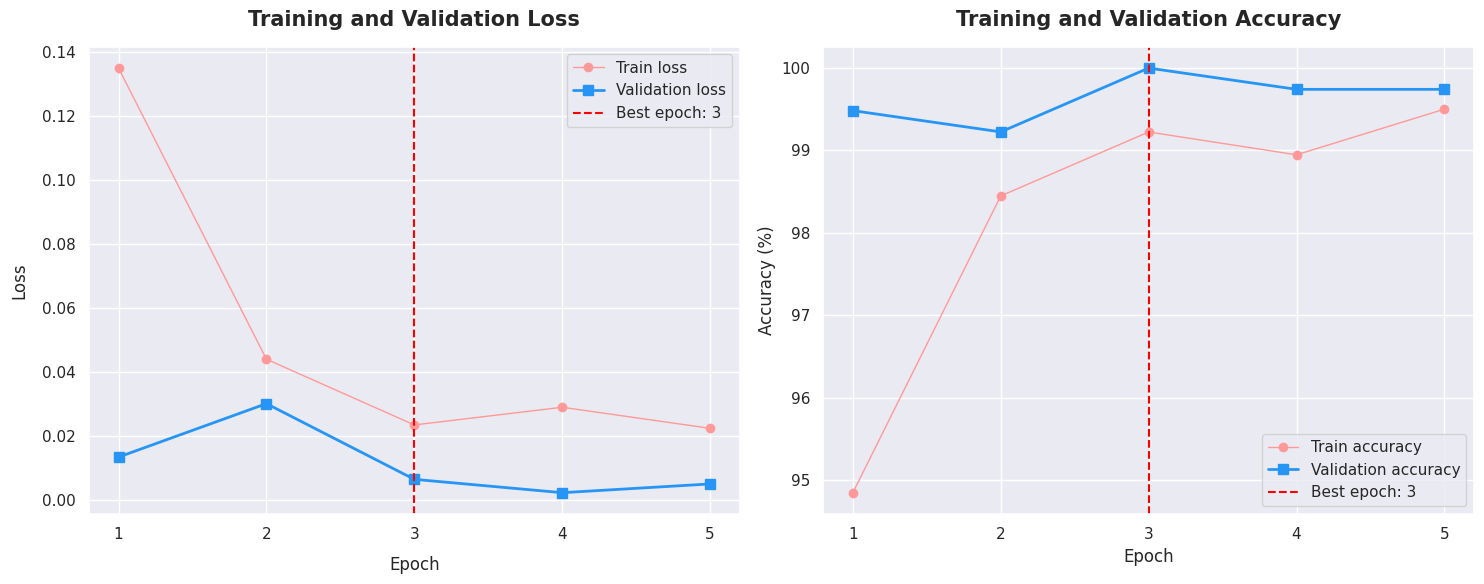

In [124]:
epoch_range = range(1, 1 + EPOCHS)

best_epoch = np.argmax(valid_accuracies) + 1
best_acc = np.max(valid_accuracies)

plt.figure(figsize = (15, 6))

plt.subplot(1, 2, 1)
plt.title("Training and Validation Loss", fontsize = 15, fontweight = "bold", pad = 15)

plt.plot(epoch_range, train_losses, label = "Train loss", color = "#FF9999", linewidth = 1, marker = "o", markersize = 6)
plt.plot(epoch_range, valid_losses, label = "Validation loss", linewidth = 2, color = "#2795F5", marker = "s", markersize = 7)
plt.axvline(x = best_epoch, color = "red", linestyle = "--", label = f"Best epoch: {best_epoch}")
plt.xlabel("Epoch", fontsize = 12, labelpad = 10)
plt.ylabel("Loss", fontsize = 12, labelpad = 10)
plt.xticks(epoch_range)
plt.legend(fontsize = 11)

plt.subplot(1, 2, 2)
plt.title("Training and Validation Accuracy", fontsize = 15, fontweight = "bold", pad = 15)
plt.plot(epoch_range, train_accuracies, label = "Train accuracy", color = "#FF9999", linewidth = 1, marker = "o", markersize = 6)
plt.plot(epoch_range, valid_accuracies, label = "Validation accuracy", linewidth = 2, color = "#2795F5", marker = "s", markersize = 7)
plt.axvline(x = best_epoch, color = "red", linestyle = "--", label = f"Best epoch: {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epoch_range)
plt.legend(fontsize = 11)

plt.tight_layout()
plt.show()

## Part 6

In this final section, we tackle the discrepancy between the raw image dimensions (we have seen that it is 700x500) and the strict input size required by the Vision Transformers (224x224). There are many options to solve our problem. We can compress/rescale the image into desired resolution, but since we are dealing with the medical image dataset we cannot allow to accidently deform any images. Another possibility would be to perform for example a center crop, yet again we will bias our prediction solely based on the centre of an image, completely avoiding other parts.

With that in mind, we implement a sliding-window strategy. We systematically pass a 224x224 window with a 112-pixel stride over the full image, therefore we extract multiple local patches. The final classification for the entire image is then determined by averaging the softmax probabilities across all the patches.

#### Sliding Window Inference

In [58]:
def inference_sliding_window(model, img_path):
    '''
    Performs inference on an image using a sliding window approach.

    Args:
        model (torch.nn.Module): The model to use for inference.
        img_path (str): The path to the image to be inferred.

    Returns:
        str: The predicted class label.
    '''

    WINDOW_SIZE = 224
    STRIDE = 112

    image = Image.open(img_path).convert("RGB")
    width, height = image.size

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(*IMAGENET_STATS)
    ])

    idx2label = {idx: label for label, idx in label2idx.items()}

    all_probabilities = []
    patch = 0

    model.eval()
    with torch.no_grad():
        for i in range(0, height - WINDOW_SIZE + 1, STRIDE):
            for j in range(0, width - WINDOW_SIZE + 1, STRIDE):
                window = image.crop((j, i, j + WINDOW_SIZE, i + WINDOW_SIZE))
                patch_tensor = transform(window).unsqueeze(0).to(device)

                output = model(patch_tensor)
                probability = output.softmax(dim = 1).squeeze(0)

                probabilities_dict = {idx2label[i]: probability[i].item() for i in range(len(idx2label))}
                all_probabilities.append(probabilities_dict)

                print(f"Patch {patch}: {probabilities_dict}")

                patch += 1

    averaged_probs = {}
    for class_n in idx2label.values():
        prob_sum = sum(probabilities_dict[class_n] for probabilities_dict in all_probabilities)
        averaged_probs[class_n] = prob_sum / len(all_probabilities)

    print(f"Average: {averaged_probs}")

    out_class = max(averaged_probs, key = averaged_probs.get)
    print(f"Final class: {out_class}")

    return out_class

In [136]:
result = inference_sliding_window(model, os.path.join(images_dir, "5.png"))

Patch 0: {'astro': 9.311892057439763e-08, 'cort': 0.9999998807907104, 'shsy5y': 5.62694557615373e-09}
Patch 1: {'astro': 2.3504182422584563e-07, 'cort': 0.9999997615814209, 'shsy5y': 7.607813046206502e-09}
Patch 2: {'astro': 1.4827941541284417e-08, 'cort': 1.0, 'shsy5y': 2.387949393778399e-09}
Patch 3: {'astro': 7.713292227151669e-09, 'cort': 1.0, 'shsy5y': 1.5821780552371933e-09}
Patch 4: {'astro': 1.322684255455897e-07, 'cort': 0.9999998807907104, 'shsy5y': 2.7543796132789566e-09}
Patch 5: {'astro': 8.643174176370394e-09, 'cort': 1.0, 'shsy5y': 2.368439666611266e-09}
Patch 6: {'astro': 1.6266278990428873e-08, 'cort': 1.0, 'shsy5y': 2.9643780763422e-09}
Patch 7: {'astro': 8.415415031493012e-09, 'cort': 1.0, 'shsy5y': 1.5839807243622772e-09}
Patch 8: {'astro': 4.579144619043518e-09, 'cort': 1.0, 'shsy5y': 9.229589870152211e-10}
Patch 9: {'astro': 7.75924462459443e-08, 'cort': 0.9999998807907104, 'shsy5y': 1.3860224079564887e-09}
Patch 10: {'astro': 1.3029134038333723e-07, 'cort': 0.999

#### Evaluation

So far we have seen the results on train and validation datasets. We have also seen how the model performs under various hyperparameters, including the number of epochs, transformations and learning rates. Now we shall examine performance of the best model on the test dataset - the one which has been "hidden" throughout the entire notebook and especially the training phase. To do so, we need to load the weights/model we saved during evaluation phase in Part 5.

In [137]:
model.load_state_dict(torch.load("./model.pth", weights_only=True))

<All keys matched successfully>

With that being said, we can now summarise statistics obtained on the test dataset, specific for image classification problems, such as accuracy, recall and precision. What can be noticed is that the model demonstrates near-perfect classification capabilities, achieving an overall accuracy of about 99% across the samples it has never seen before. What is more, the performance metrics indicate that it generalised well without any significant bias towards any specific minority class we have seen earlier.

In [138]:
all_predictions = []
all_ground_truths = []

model.eval()
with torch.inference_mode():
    for images, labels in tqdm(test_loader, desc = "Evaluation"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_ground_truths.extend(labels.cpu().numpy())

class_names = [test_dataset.idx2label[i] for i in range(test_dataset.num_classes)]

print("---------------- CLASSIFICATION REPORT ----------------\n")
print(classification_report(all_ground_truths, all_predictions, target_names = class_names))

Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

---------------- CLASSIFICATION REPORT ----------------

              precision    recall  f1-score   support

       astro       1.00      0.99      0.99       171
        cort       0.99      1.00      1.00       122
      shsy5y       0.99      1.00      0.99        94

    accuracy                           0.99       387
   macro avg       0.99      1.00      0.99       387
weighted avg       0.99      0.99      0.99       387



Despite nearly perfect metrics achieved by our model, we can still see some cases in which model made a wrong decision. By looking at the confusion matrix, we can see that in few cases it predicted astro while the ground truth label was shsy5y. It should not be surprising, however, since we have seen the proportions of classes in the dataset. Because of the fact that shsy5y was an underrepresented class compared to astro the model had fewer training examples from which to learn its unique features. Consequently, when presented with ambiguous characteristics, the model is statistically more prone to default its prediction to the dominan class, showing a bias typical of imbalanced datasets.

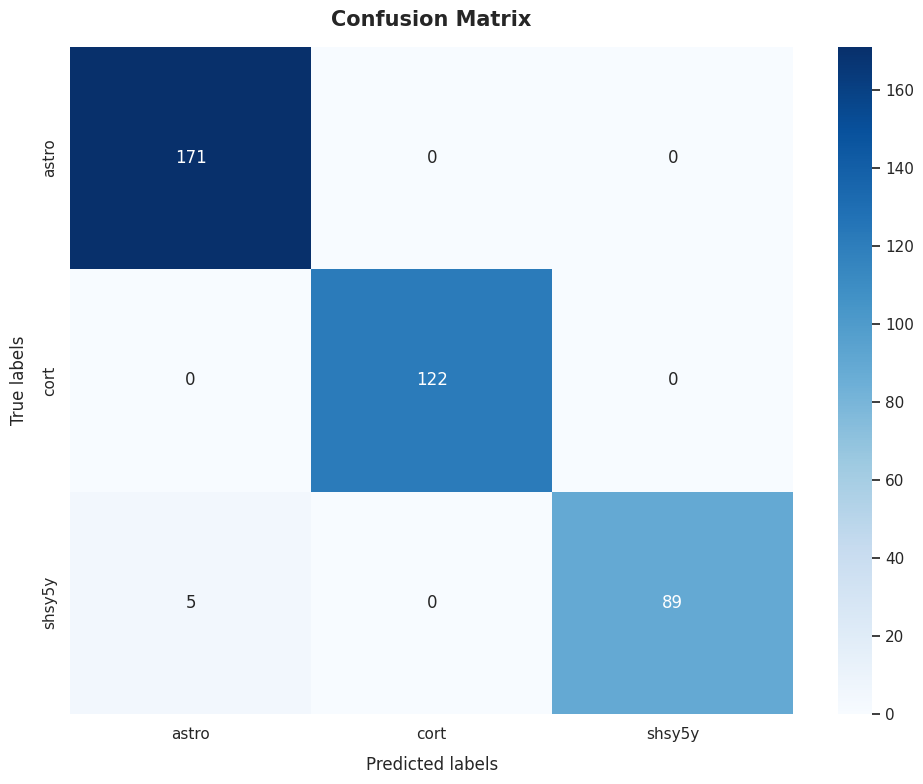

In [133]:
cmatrix = confusion_matrix(all_ground_truths, all_predictions)

plt.figure(figsize = (10, 8))
sns.heatmap(cmatrix, annot = True, fmt = "d", cmap = "Blues", xticklabels = class_names, yticklabels = class_names)

plt.title("Confusion Matrix", fontsize = 15, fontweight = "bold", pad = 15)
plt.xlabel("Predicted labels", fontsize = 12, labelpad = 10)
plt.ylabel("True labels", fontsize = 12, labelpad = 10)

plt.tight_layout()
plt.show()

With that being said, we can now visualise some samples from the test dataset. We would also like to see in which cases (if applicable) the model made the wrong decisions to further examine what can be done to possibly improve the training phase. For example, to mitigate problems described above, we can equip our solution with techniques such as class weighting in the loss function or additional data augmentation specific to the minority class.

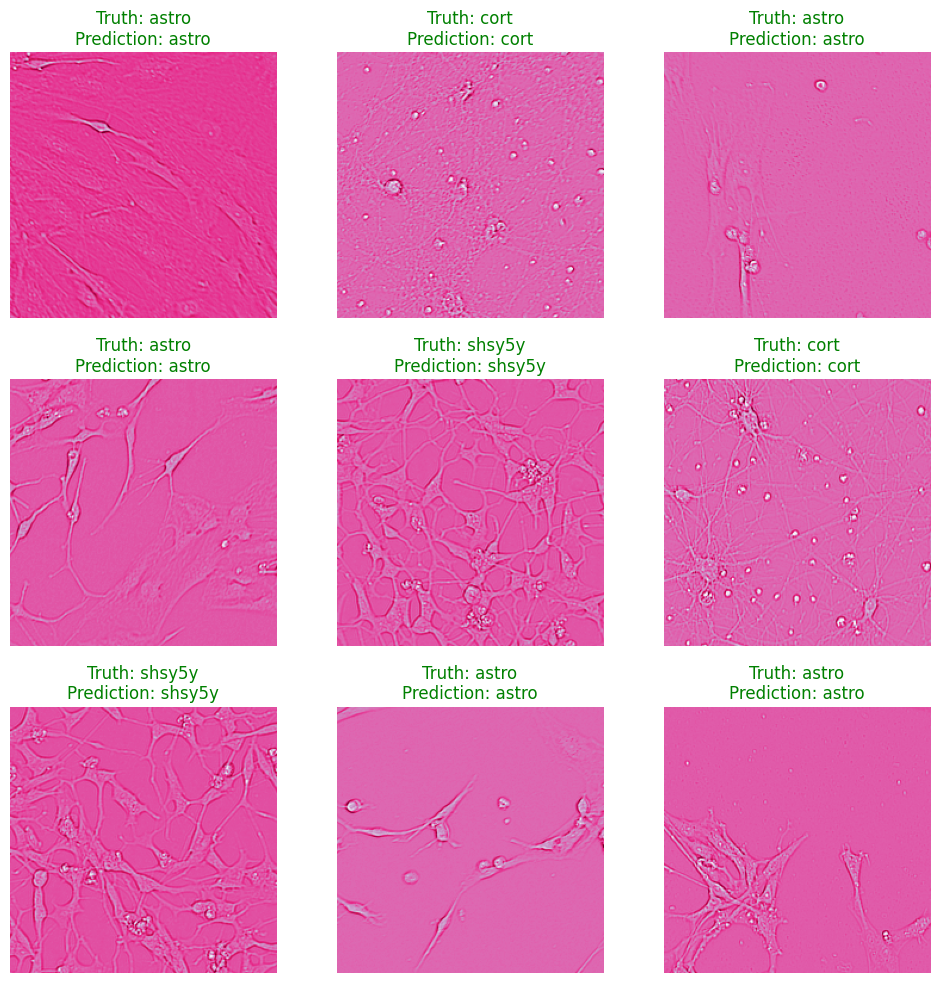

In [135]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.inference_mode():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(3, 3, figsize = (10, 10))
axes = axes.flatten()

mean, std = np.array(IMAGENET_STATS[0]), np.array(IMAGENET_STATS[1])

for i in range(9):
    image = images[i].permute(1, 2, 0).cpu().numpy()
    image = std * image + mean
    image = np.clip(image, 0, 1)

    image = image[:, :, 0]

    truth = test_dataset.idx2label[labels[i].item()]
    prediction = test_dataset.idx2label[predicted[i].item()]

    title_colour = "green" if truth == prediction else "red"

    axes[i].imshow(image, cmap = "PuRd")
    axes[i].set_title(f"Truth: {truth}\nPrediction: {prediction}", color = title_colour)
    axes[i].axis(False)

plt.tight_layout()
plt.show()

## References



*   ViT16 documentation - https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html
*   SwinT paper - https://arxiv.org/pdf/2103.14030
* Colour maps - https://matplotlib.org/stable/users/explain/colors/colormaps.html$0
* ViT objectives - https://www.robots.ox.ac.uk/~vgg/practicals/overview/#vision-transformers$0

---



logo_lg.svg